Declarations

In [1]:
%matplotlib widget

import datetime, matplotlib, openpyxl, os, re
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from collections import defaultdict
from IPython.display import display
from ipywidgets import interact
from matplotlib.colors import to_rgb
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from openpyxl.utils import get_column_letter
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.optimize import linear_sum_assignment
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from types import SimpleNamespace

Set Analysis and Visualization Parameters

In [2]:
# Analysis Options
file_name        = "DataTable_CGE-Transplant_Final-noFS.xlsx" # Excel filename in same folder as this notebook
dir_out          = None          # Only need to specify if you want a specific subfolder for output, otherwise defaults to file_name_YYMMDD_HHMM
nPC              = 7             # previously hard-coded to 3, I have been adjusting to meet 95th percentile of cumulative variance plot (?)
k_range          = range(2, 11)  # Range of k-value to perform clustering over (excludes top value) 
k_default        = 5             # just for default visualization - can change to any within k_range
mode_default     = "pca"         # just for default visualization - can take values "raw", "normalized", or "pca"
optimal_order    = False         # Hierarchical linkage option. If True, linkage matrix will be reordered so that the distance between successive leaves is minimal.

# List of feature names to exclude from analysis
exclude_features = ["RMP", "sag", "freq_inst", "accom_ISI", "thresh", "amp", "AHP_amp", "sEPSC_freq", "sEPSC_amp", "sEPSC_rise", "sEPSC_decay"]         

# Display options
SHOW_PLOTS       = True          # Will display interactive diagnostic plots inline
DARK_MODE        = False         # Switches plot fonts to white to work with dark mode
EXPORT_SVG       = True          # Exports SVG images
EXPORT_PDF       = True          # Exports PDF images
FDR_ANOVA        = True          # Used FDR p-values for feature ANOVA significance, otherwise Bonferroni
GLOBAL_MAX_ANOVA = True          # Sets common max feature ANOVA value across data representations for consistent colormap
CM_PER_INCH      = 2.54          # Conversion from cm to inches
max_plot_width   = 14            # In inches, 14 works well for 4k external display - reduce if needed for smaller screens, doesn't scale fonts

# Vector mode
%config InlineBackend.figure_format = "svg" 

# Calculated params (don't need to change - unless you want to change colormap)
k_vals     = list(k_range)
palette    = sns.color_palette("tab10", max(k_range)) # Color map

# Match theme settings
if DARK_MODE:
    fg = "white"   # For text, lines of plots
    bg = "#1e1e1e" # For background "empty" areas of plot that cannot be made full transparency
    st = "dark"    # Seaborn style
else:
    fg = "black"
    bg = "white"
    st = "white"

# Set default plot (seaborn) style
sns.set_palette(palette, desat=None)
sns.set_theme(
    style=st,
    rc={

        # Default Font Settings
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Liberation Sans", "DejaVu Sans"],

        # Set transparency
        "figure.facecolor": (0, 0, 0, 0),
        "axes.facecolor": (0, 0, 0, 0),

        # Foreground colors
        "axes.edgecolor": fg,
        "axes.labelcolor": fg,
        "xtick.color": fg,
        "ytick.color": fg,
        "text.color": fg,

        # Font sizes
        "font.size":       8,    # base font size
        "axes.titlesize":  8,    # subplot titles
        "axes.labelsize":  8,    # x/y labels
        "xtick.labelsize": 6,    # tick labels
        "ytick.labelsize": 6,
        "legend.fontsize": 8,

        "axes.linewidth": 0.5,

        # X tick marks
        "xtick.major.size": 2,
        "xtick.major.width": 0.5,
        "xtick.minor.size": 1,
        "xtick.minor.width": 0.5,
        "xtick.direction": "out",

        # Y tick marks
        "ytick.major.size": 2,
        "ytick.major.width": 0.5,
        "ytick.minor.size": 1,
        "ytick.minor.width": 0.5,
        "ytick.direction": "out",

        # Tick defaults
        "xtick.bottom": True,
        "xtick.top": False,
        "ytick.left": True,
        "ytick.right": False,
        }
)

Validate file name and initialize output directly and functions


In [3]:
# Validate file_name
if not file_name or not file_name.strip():
    raise ValueError("file_name cannot be empty. Please set file_name to a valid filename.")

base_name = os.path.splitext(file_name)[0] # Strip extension

# Set output directory if not specified
if not dir_out or not dir_out.strip(): dir_out = f"{base_name}_{datetime.datetime.now().strftime("%y%m%d_%H%M")}"

os.makedirs(dir_out, exist_ok=True)
print(f"Export directory created: {dir_out}")

# Helper function to auto-increment filename if it already exists, to avoid overwriting previous exports
def auto_increment(path):
    if not os.path.exists(path):
        return path
    base, ext = os.path.splitext(path)
    i = 1
    while True:
        new = f"{base}_{i}{ext}"
        if not os.path.exists(new):
            return new
        i += 1

# Export figure function
def export_fig(fig=None, fig_name=None, export_svg=EXPORT_SVG, export_pdf=EXPORT_PDF, export_width_cm=None, export_height_cm=None):

    # Determine figure to export
    if fig is None:
        fig = plt.gcf()
    
    # Determine base filename
    if fig_name is None or not fig_name.strip():

        # Look for suptitle first
        if fig._suptitle:
            fig_name = "Figure"

        # Else if look for title of axes
        elif fig.axes:

            # find the first non-empty axes title
            for ax in fig.axes:
                t = ax.get_title().strip()
                if t:
                    fig_name = t
                    break

            # Else default to file name
            else:
                fig_name = os.path.splitext(file_name)[0]

    # Sanitize fig_name
    fig_name = re.sub(r'[^A-Za-z0-9_.-]+', '_', fig_name) or "Figure"

    # Compute export size in inches (if requested)
    orig_size = fig.get_size_inches()  # always save so we can restore
    
    if export_width_cm is not None:
        export_w = export_width_cm / CM_PER_INCH
        if export_height_cm is not None:
            export_h = export_height_cm / CM_PER_INCH
        else:
            # Preserve display aspect ratio
            aspect = orig_size[1] / orig_size[0]
            export_h = export_w * aspect
        fig.set_size_inches(export_w, export_h)

    # Save using the current canvas without switching backends and without triggering a redraw.
    fig.canvas.draw_idle()
    
    try:
        # Export SVG
        if export_svg:
            svg_path = auto_increment(os.path.join(dir_out, f"{fig_name}.svg"))
            fig.savefig(svg_path)
            print(f"Exported figure {svg_path}")

        # Export PDF
        if export_pdf:
            pdf_path = auto_increment(os.path.join(dir_out, f"{fig_name}.pdf"))
            fig.savefig(pdf_path)
            print(f"Exported figure {pdf_path}")

    finally:
        # Always restore display size, even if saving raised an exception
        fig.set_size_inches(orig_size)
        fig.canvas.draw_idle()

Export directory created: DataTable_CGE-Transplant_Final-noFS_260715_0910


Process Data. Each row corresponds to a neuron and each column to a feature, 1st 2 columns are labels, with metadata/unit row below header. Clean data by excluding rows with missing values. Store cell came, ID, units, and if present, categorical columns in separate dataframes to isolate numerical feature dataframe (clean). Use standard scaler (z-score to normalize data)

In [4]:
# Import raw data
data_raw = pd.read_excel(file_name, header=0)

# Extract col_details row (row index 1)
col_details = data_raw.iloc[0].copy()

 # Drop col_details from dataset
data_clean = data_raw.drop(index=0).reset_index(drop=True)

# Drop columns supplied in exclude_features list
if exclude_features:

    # Split into valid + invalid
    valid_exclusions   = [f for f in exclude_features if f in data_clean.columns]
    invalid_exclusions = [f for f in exclude_features if f not in data_clean.columns]

    if valid_exclusions:
        print(f"Dropping feature(s) {valid_exclusions} supplied by user in exclude_features")
        data_clean  = data_clean.drop(columns=valid_exclusions)
        col_details = col_details.drop(labels=valid_exclusions, errors="ignore")

    if invalid_exclusions:
        print(f"Warning: Features {invalid_exclusions} not found and not dropped")

# Drop columns that are entirely blank (either NaN or empty string)
blank_cols = [
    col for col in data_clean.columns
    if data_clean[col].isna().all()
    or data_clean[col].astype(str).str.strip().eq("").all()
]

if blank_cols:
    print(f"Dropping feature(s) {blank_cols} due to being entirely blank")
    data_clean  = data_clean.drop(columns=blank_cols)
    col_details = col_details.drop(labels=blank_cols, errors="ignore")

# Drop rows with missing values
missing    = data_clean[data_clean.isna().any(axis=1)] 
data_clean = data_clean.dropna(how="any").reset_index(drop=True)
if not missing.empty:
    missingCells = missing["Cell"].tolist()
    print(f"Dropping cell(s) {missingCells} due to missing values")

# Extract labels and drop label columns
lab_cols   = ["Cell", "Cell_ID"]
cell_name  = data_clean[lab_cols[0]].values
cell_ID    = data_clean[lab_cols[1]].values
data_clean = data_clean.drop(lab_cols, axis=1)

# Identify categorical columns, extract, and drop from data
cat_cols   = col_details[col_details == "categorical"].index.tolist()
data_categorical = data_clean[cat_cols].copy()
data_clean = data_clean.drop(columns=cat_cols)
num_cols   = data_clean.columns.tolist()
if cat_cols:
    print(f"Categorical features: {cat_cols}")

# Force all data columns to numeric
data_clean = data_clean.apply(pd.to_numeric, errors="coerce")

# Extract units for numeric columns
units = col_details[data_clean.columns].fillna("")

print(f"Numerical features: {data_clean.columns.tolist()}")
print(f"Units {units.tolist()}")

# Normalize data
scaler = StandardScaler()
data_norm = pd.DataFrame(
    scaler.fit_transform(data_clean),
    index = data_clean.index,
    columns = data_clean.columns)

Dropping feature(s) ['RMP', 'sag', 'freq_inst', 'accom_ISI', 'thresh', 'amp', 'AHP_amp', 'sEPSC_freq', 'sEPSC_amp', 'sEPSC_rise', 'sEPSC_decay'] supplied by user in exclude_features
Dropping cell(s) ['KP18', 'RC11'] due to missing values
Numerical features: ['tau', 'Rin', 'sag_ratio', 'freq_max', 'delay_spike', 'freq_ratio', 'half_width', 'max_up', 'max_down', 'AHP_time']
Units ['ms', 'MΩ', '', 'Hz', 'ms', '', 'ms', 'mV/ms', 'mV/ms', 'ms']


Principal Component Analysis (PCA)

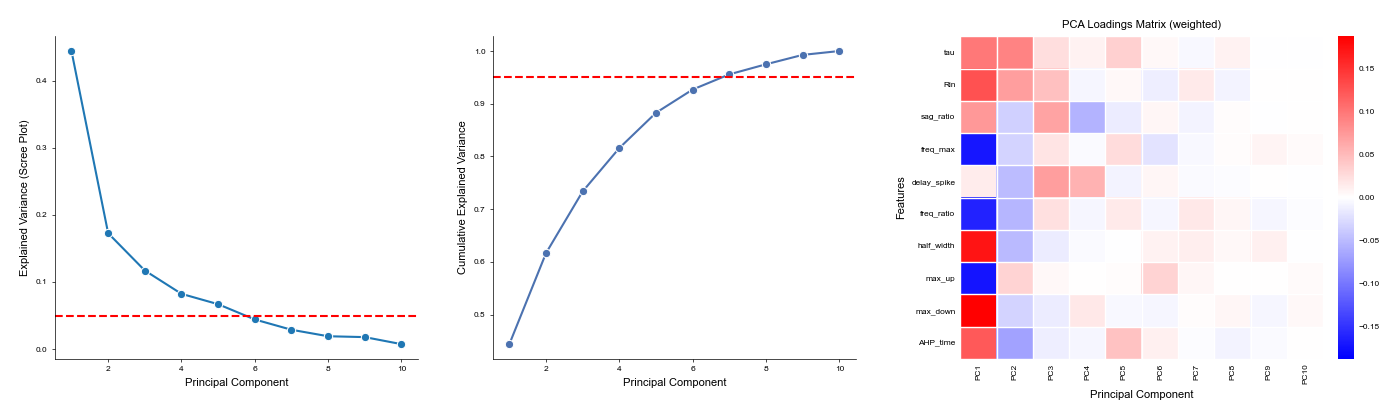

In [5]:
# PCA with all components
pca_full = PCA()
pca_full = pca_full.fit(data_norm)

# Explained variance
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Loadings matrix (features × PCs)
loading = pca_full.components_.T
loading_weighted = loading * explained # weighted by explained variance
loading_df = pd.DataFrame(loading_weighted, index=data_norm.columns, columns=[f"PC{i+1}" for i in range(loading_weighted.shape[1])])

# Final PCA with specified number of components nPC on normalized data
pca      = PCA(n_components = nPC)
arr_pca  = pca.fit_transform(data_norm)
data_pca = pd.DataFrame(
    arr_pca,
    index = data_clean.index,
    columns=[f"PC{i+1}" for i in range(arr_pca.shape[1])]
)

if SHOW_PLOTS:

    plt.close('all')

    fig, (ax_scree, ax_cum, ax_load) = plt.subplots(1, 3, figsize=(max_plot_width, 0.3*max_plot_width), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.2, h_pad=0.2)
    fig.canvas.header_visible = False
    
    # Scree Plot
    sns.lineplot(x=range(1, len(explained)+1), y=explained, marker='o', ax=ax_scree, color=palette[0])
    sns.despine(ax=ax_scree)
    ax_scree.axhline(0.05, color='red', linestyle='--')
    ax_scree.set_xlabel("Principal Component")
    ax_scree.set_ylabel("Explained Variance (Scree Plot)")

    # Cumulative Variance Plot
    sns.lineplot(x=range(1, len(cum_explained)+1), y=cum_explained, marker='o', ax=ax_cum)
    sns.despine(ax=ax_cum)
    ax_cum.axhline(0.95, color='red', linestyle='--')
    ax_cum.set_xlabel("Principal Component")
    ax_cum.set_ylabel("Cumulative Explained Variance")

    # Feature Loadings/Importance Heatmap
    def loadings_heatmap(ax, df, cmap="bwr", vmin=-1, vmax=1, ylabel="Features", title="PCA Loadings Matrix"):

        vals = df.values
        im = ax.imshow(vals, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto", interpolation="none")

        # Add white gridlines between cells
        ax.set_xticks(np.arange(vals.shape[1]+1)-0.5, minor=True)
        ax.set_yticks(np.arange(vals.shape[0]+1)-0.5, minor=True)
        ax.grid(which="minor", color=bg, linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)

        # Tick labels
        ax.set_xticks(np.arange(vals.shape[1]))
        ax.set_xticklabels(df.columns, rotation=90, fontsize=6)
        ax.set_yticks(np.arange(vals.shape[0]))
        ax.set_yticklabels(df.index, fontsize=6)
        ax.tick_params(axis="both", which="both", length=0)
        
        # Remove black border
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Colorbar
        cbar = ax.figure.colorbar(im, ax=ax, location="right", anchor=(0.0, 0.5), shrink=1.0, pad=0.04)
        cbar.outline.set_visible(False)
        cbar.ax.tick_params(which="both", length=0)

        ax.set_title(title)
        ax.set_xlabel("Principal Component")
        ax.set_ylabel(ylabel)

    v = np.abs(loading_df.values).max()
    loadings_heatmap(ax_load, loading_df, vmin=-v, vmax=v, ylabel="Features", title="PCA Loadings Matrix (weighted)")

    plt.show()

Export PCA Diagnostics figure

In [6]:
export_fig(fig, fig_name="PCA_Diagnostics")

Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\PCA_Diagnostics.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\PCA_Diagnostics.pdf


k-Means Clustering Analysis: run iteratively over data modes and values of k 

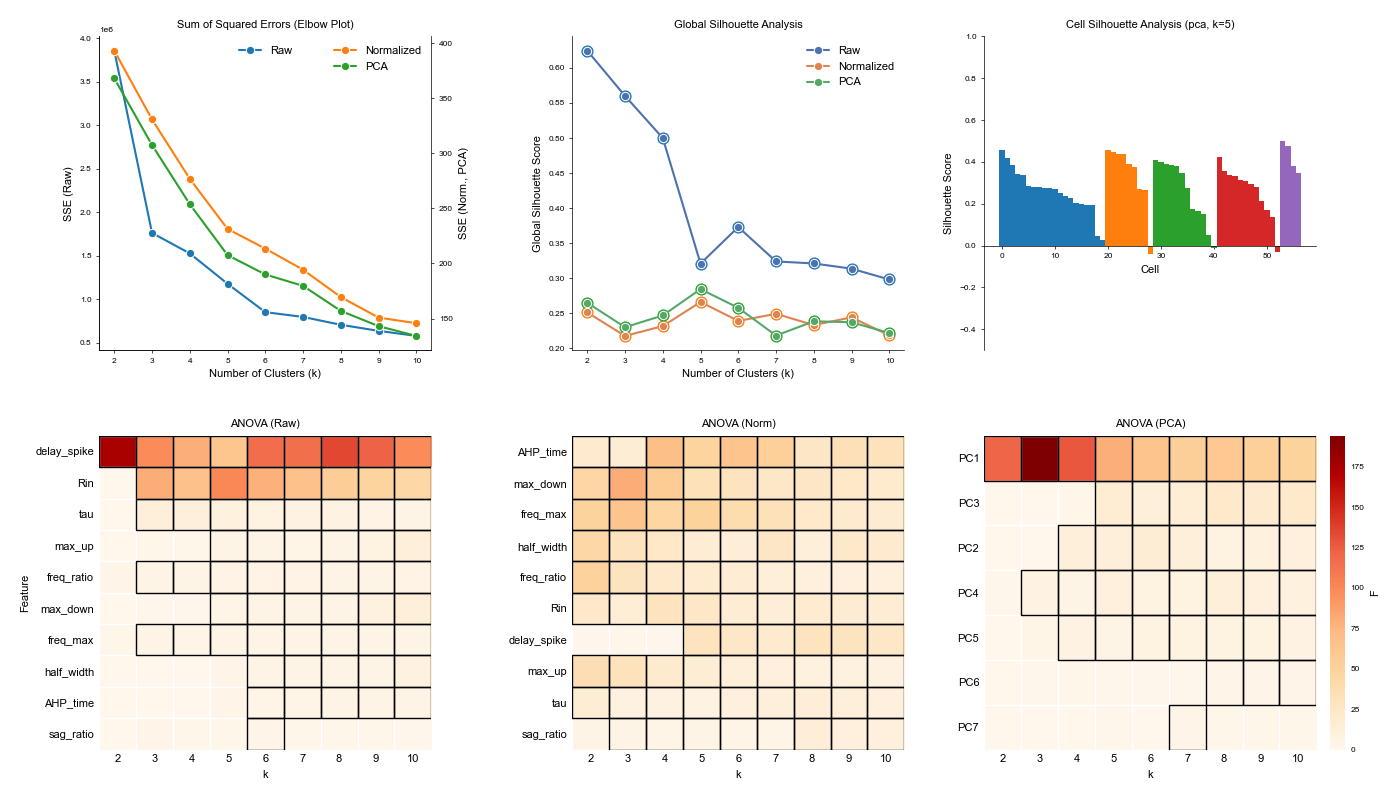

In [7]:
def kmeans_analysis(data, k_range=k_range):
    """
    Runs k-means analysis on input (cleaned, normalized, or PCA) data.
    Returns namespace with:
        .data:           input DataFrame
        .k_range:        input k_range
        .kmeans:         dict of fitted KMeans model
        .lables:         dict of cluster labels for each data point
        .centroids:      dict of cluster centroids in the input feature space
        .centroids_dist: dict of distances from each point to its assigned centroid
        .sse:            dict of inertia values
        .sil:            dict of global silhouette scores
        .sil_cell:       dict of per-cell silhouette score
        .feature_anova:  dict of ANOVA tables per k, sorted by F
    """

    X = data.to_numpy(dtype=float)
    feature_names = data.columns

    # Initialize namespace
    out = SimpleNamespace(
        data           = data,
        k_range        = k_range,
        kmeans         = {},
        labels         = {},
        centroids      = {},
        centroids_dist = {},
        sse            = {},
        sil            = {},
        sil_cell       = {},
        feature_anova  = {}
    )

    # Iterate through k_range
    for k in k_range:
        out.kmeans[k]         = KMeans(n_clusters=k, max_iter=1000, random_state=0)
        out.labels[k]         = out.kmeans[k].fit_predict(data.values)
        out.centroids[k]      = out.kmeans[k].cluster_centers_
        out.centroids_dist[k] = np.linalg.norm(X - out.centroids[k][out.labels[k]], axis=1)
        out.sse[k]            = out.kmeans[k].inertia_
        out.sil[k]            = silhouette_score(data, out.labels[k])
        out.sil_cell[k]       = silhouette_samples(data, out.labels[k])

        # ANOVA feature importance, sorting by descending F
        F, p = f_classif(X, out.labels[k])
        p_bonf = np.minimum(p * len(p), 1.0)
        _, p_fdr, _, _ = multipletests(p, method='fdr_bh')
        df = pd.DataFrame([F, p, p_bonf, p_fdr], index=["F", "p", "p_bonf", "p_fdr"], columns=feature_names)
        df = df.loc[:, df.loc["F"].sort_values(ascending=False).index]
        out.feature_anova[k] = df

    return out

# Run k-means clustering analysis on different data representations
kmeans_clean = kmeans_analysis(data_clean, k_range=k_range)
kmeans_norm  = kmeans_analysis(data_norm, k_range=k_range)
kmeans_pca   = kmeans_analysis(data_pca, k_range=k_range)

# Determine default structure based on mode_default
if mode_default   == "raw":
    kmeans_default = kmeans_clean
elif mode_default == "normalized":
    kmeans_default = kmeans_norm
elif mode_default == "pca":
    kmeans_default = kmeans_pca
else:
    raise ValueError(f"Invalid mode_default: {mode_default}")

# Optionally show diagnostic plots
if SHOW_PLOTS:

    plt.close('all')

    fig, axes = plt.subplots(2, 3, figsize=(max_plot_width, max_plot_width*4/7), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.2, h_pad=0.2)
    fig.canvas.header_visible = False
    
    # First row
    ax_sse1     = axes[0, 0]
    ax_sil      = axes[0, 1]
    ax_sil_cell = axes[0, 2]

    # Second row: feature ANOVA heatmaps
    ax_anova_raw  = axes[1, 0]
    ax_anova_norm = axes[1, 1]
    ax_anova_pca  = axes[1, 2]

    # ----- SSE (Elbow Plot)  -----

    # Left axis for Raw SSE
    sns.lineplot(x=k_vals, y=list(kmeans_clean.sse.values()), marker='o', ax=ax_sse1, color=palette[0], label="Raw")
    ax_sse1.set_xlabel("Number of Clusters (k)")
    ax_sse1.set_ylabel("SSE (Raw)")

    # Right axis for Normalized + PCA SSE
    ax_sse2 = ax_sse1.twinx()
    sns.lineplot(x=k_vals, y=list(kmeans_norm.sse.values()), marker='o', ax=ax_sse2, color=palette[1], label="Normalized")
    sns.lineplot(x=k_vals, y=list(kmeans_pca.sse.values()), marker='o', ax=ax_sse2, color=palette[2], label="PCA")
    ax_sse2.set_ylabel("SSE (Norm., PCA)")

    # Title + legend
    ax_sse1.set_title("Sum of Squared Errors (Elbow Plot)")
    ax_sse1.legend(loc="upper center", frameon=False)
    ax_sse2.legend(loc="upper right", frameon=False)
    sns.despine(ax=ax_sse1, right=False)
    sns.despine(ax=ax_sse2, left=False)

    # ----- Global Silhouette Plot -----
    sns.lineplot(x=list(kmeans_clean.sil.keys()), y=list(kmeans_clean.sil.values()), marker='o', ax=ax_sil, label="Raw")
    sns.lineplot(x=list(kmeans_norm.sil.keys()), y=list(kmeans_norm.sil.values()), marker='o', ax=ax_sil, label="Normalized")
    sns.lineplot(x=list(kmeans_pca.sil.keys()),  y=list(kmeans_pca.sil.values()), marker='o', ax=ax_sil, label="PCA")

    # Add clickable scatter overlays to choose sil_cell plot
    ax_sil.scatter(x=list(kmeans_clean.sil.keys()), y=list(kmeans_clean.sil.values()), s=60, color=palette[0], picker=True)
    ax_sil.scatter(x=list(kmeans_norm.sil.keys()), y=list(kmeans_norm.sil.values()), s=60, color=palette[1], picker=True)
    ax_sil.scatter(x=list(kmeans_pca.sil.keys()), y=list(kmeans_pca.sil.values()), s=60, color=palette[2], picker=True)

    ax_sil.set_xlabel("Number of Clusters (k)")
    ax_sil.set_ylabel("Global Silhouette Score")
    ax_sil.set_title("Global Silhouette Analysis")
    ax_sil.legend(loc="upper right", frameon=False)
    sns.despine(ax=ax_sil)

    # ----- Cell Silhouette Plot -----

    # Define pick handler
    def on_kmeans_sil_pick(event):
        artist = event.artist
        ind = event.ind[0]

        # Extract clicked x-value (k)
        k_clicked = int(artist.get_offsets()[ind, 0])

        # Determine which dataset was clicked by color
        color = tuple(artist.get_facecolors()[0][:3])

        if color == tuple(palette[0]): # Raw
            sil_dict = kmeans_clean.sil_cell
            labels   = kmeans_clean.labels
            mode     = "Raw"
        elif color == tuple(palette[1]): # Normalized
            sil_dict = kmeans_norm.sil_cell
            labels   = kmeans_norm.labels
            mode     = "Normalized"
        else: # PCA
            sil_dict = kmeans_pca.sil_cell
            labels   = kmeans_pca.labels
            mode     = "PCA"

        update_sil_cell_plot(k_clicked, sil_dict, labels, mode, ax_sil_cell)

    # Define sil_cell update function
    def update_sil_cell_plot(k, sil_dict, labels_dict, mode, ax):
        ax.clear()

        y = sil_dict[k]
        labels = labels_dict[k]

        # Sort by cluster, then by silhouette descending
        order = np.lexsort((-y, labels))
        y_sorted = y[order]
        labels_sorted = labels[order]

        x = np.arange(len(y))

        ax.bar(x, y_sorted, color=[palette[c] for c in labels_sorted], width=1, linewidth=0)
        ax.set_title(f"Cell Silhouette Analysis ({mode}, k={k})")
        ax.set_ylim(-0.5, 1)
        ax.spines['bottom'].set_position(('data', 0))
        ax.set_ylabel("Silhouette Score")
        ax.set_xlabel("Cell")
        sns.despine(ax=ax_sil_cell)
    
    # Initialize cell silhouette plot
    update_sil_cell_plot(k_default, kmeans_default.sil_cell, kmeans_default.labels, mode_default, ax_sil_cell)

    # Connect the handler
    fig.canvas.mpl_connect("pick_event", on_kmeans_sil_pick)

    # ----- Feature ANOVA heatmaps -----

    # Function to build feature ANOVA heatmap
    def feature_anova_heatmap(anova_dict, k_range, ax, title="", x_label="", y_label="", c_label="", show_cbar=True, v_max=None):

        # Build F matrix
        F_mat = pd.DataFrame({k: anova_dict[k].loc["F"] for k in k_range})

        # Compute global feature order sorted by mean F across k
        feature_order = F_mat.mean(axis=1).sort_values(ascending=False).index
        F_mat = F_mat.loc[feature_order]

        # Build significance mask
        p_key = "p_fdr" if FDR_ANOVA else "p_bonf"
        sig_mask = pd.DataFrame({k: (anova_dict[k].loc[p_key] < 0.05) for k in k_range})

        v_min = 0
        v_max = v_max if v_max is not None else F_mat.values.max()
        
        # Heatmap of F values
        vals = F_mat.values
        im = ax.imshow(vals, cmap="OrRd", vmin=v_min, vmax=v_max, aspect="auto", interpolation="none")

        # White gridlines between cells
        ax.set_xticks(np.arange(vals.shape[1] + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(vals.shape[0] + 1) - 0.5, minor=True)
        ax.grid(which="minor", color=bg, linewidth=1)
        ax.tick_params(which="minor", bottom=False, left=False)

        # Tick labels
        ax.set_xticks(np.arange(vals.shape[1]))
        ax.set_xticklabels(F_mat.columns, fontsize=8)
        ax.set_yticks(np.arange(vals.shape[0]))
        ax.set_yticklabels(F_mat.index, fontsize=8)
        ax.tick_params(axis="both", which="both", length=0)

        # Remove black border
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Colorbar
        if show_cbar:
            cbar = ax.figure.colorbar(im, ax=ax, location="right", anchor=(0.0, 0.5), shrink=1.0, pad=0.04)
            cbar.set_label(c_label)
            cbar.outline.set_visible(False)
            cbar.ax.tick_params(which="both", length=0)

        # Significance boxes
        for i, feat in enumerate(F_mat.index):
            for j, k in enumerate(F_mat.columns):
                if sig_mask.loc[feat, k]:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=1))

        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)

    # Determine maximums for ANOVA heatmaps
    v_max_clean = max(kmeans_clean.feature_anova[k].loc["F"].max() for k in k_vals)
    v_max_norm  = max(kmeans_norm.feature_anova[k].loc["F"].max() for k in k_vals)
    v_max_pca   = max(kmeans_pca.feature_anova[k].loc["F"].max() for k in k_vals)

    # Optionally, find global max
    if GLOBAL_MAX_ANOVA:
        global_vmax     = max(v_max_clean, v_max_norm, v_max_pca)
        v_max_clean     = global_vmax
        v_max_norm      = global_vmax
        v_max_pca       = global_vmax
        show_cbar_clean = False
        show_cbar_norm  = False
        show_cbar_pca   = True 
    else:
        show_cbar_clean = True
        show_cbar_norm  = True
        show_cbar_pca   = True
    
    feature_anova_heatmap(kmeans_clean.feature_anova, k_vals, ax_anova_raw,  "ANOVA (Raw)", x_label="k", y_label="Feature", show_cbar=show_cbar_clean, c_label="F", v_max=v_max_clean)
    feature_anova_heatmap(kmeans_norm.feature_anova,  k_vals, ax_anova_norm, "ANOVA (Norm)", x_label="k", show_cbar=show_cbar_norm, c_label="F", v_max=v_max_norm)
    feature_anova_heatmap(kmeans_pca.feature_anova,   k_vals, ax_anova_pca,  "ANOVA (PCA)", x_label="k", show_cbar=show_cbar_pca, c_label="F", v_max=v_max_pca)

    plt.show()

Export k-Means Diagnostics figure

In [8]:
export_fig(fig, fig_name="kMeans_Diagnostics")

Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\kMeans_Diagnostics.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\kMeans_Diagnostics.pdf


Hierarchical Clustering Analysis: run iteratively over data modes and values of k

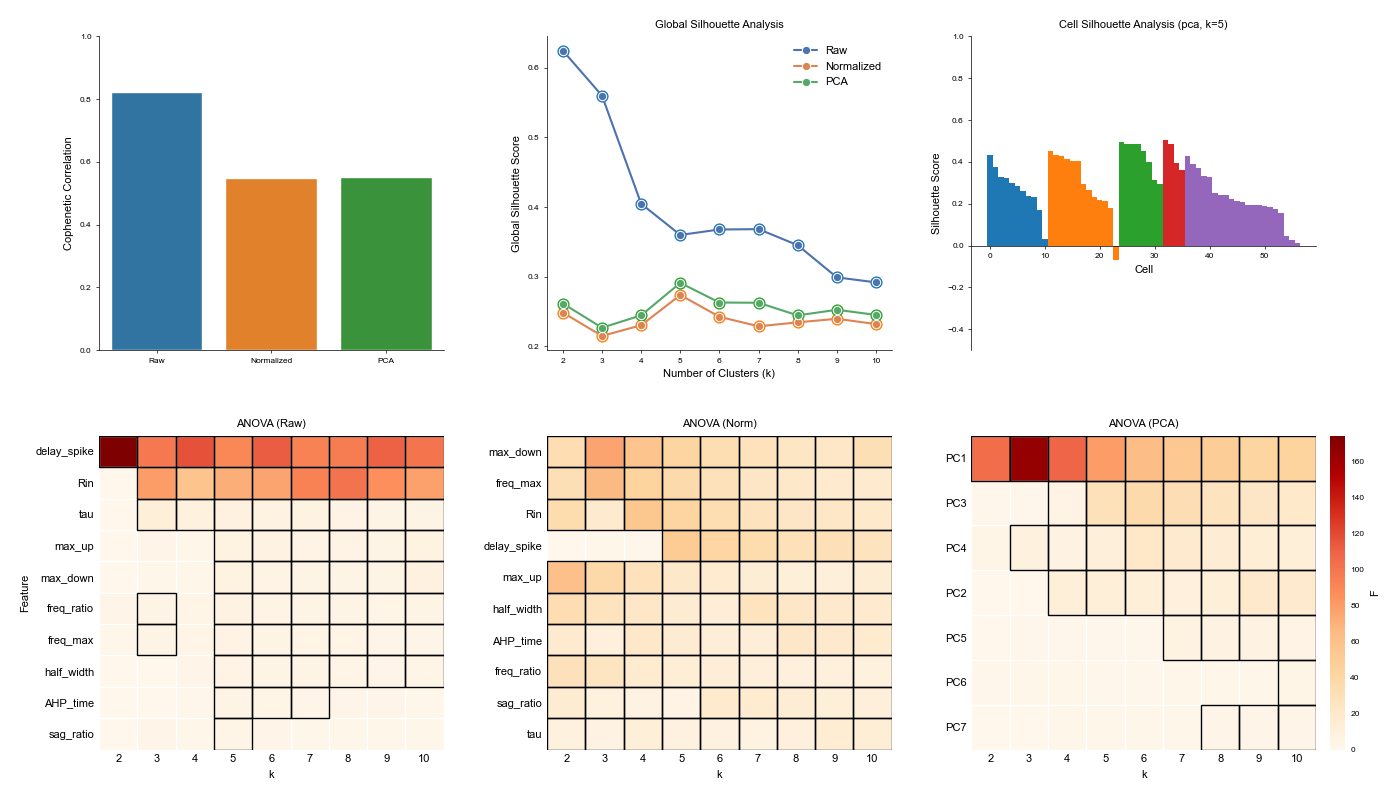

In [9]:
def hier_analysis(data, k_range=k_range, method="ward", optimal_ordering=True):
    """
    Runs hierarchical analysis on input (cleaned, normalized, or PCA) data.
    Returns namespace with:
        .data:           input DataFrame
        .k_range:        input k_range
        .Z:              Hierarchical linkage model
        .lables:         dict of cluster labels for each data point
        .centroids:      dict of cluster centroids computed from mean in the input feature space
        .centroids_dist: dict of distances from each point to its assigned centroid
        .coph_corr:      cophenetic correlation between height at which points merge and pairwise distance
        .sil:            dict of global silhouette scores
        .sil_cell:       dict of per-cell silhouette score
        .feature_anova:  dict of ANOVA tables per k, sorted by F
    """

    X = data.to_numpy(dtype=float)
    feature_names = data.columns
    Z = linkage(X, method=method, optimal_ordering=optimal_ordering) # hierarchical linkage
    coph_corr, _ = cophenet(Z, pdist(X)) # cophenetic correlation

    # Initialize namespace
    out = SimpleNamespace(
        data           = data,
        k_range        = k_range,
        Z              = Z,
        coph_corr      = coph_corr,
        labels         = {},
        centroids      = {},
        centroids_dist = {},
        sil            = {},
        sil_cell       = {},
        feature_anova  = {}
    )

    # Iterate through k_range
    for k in k_range:
        out.labels[k] = fcluster(Z, k, criterion="maxclust") - 1

        # Compute centroids
        out.centroids[k] = np.zeros((k, X.shape[1]))
        for i in range(k):
            out.centroids[k][i] = X[out.labels[k] == i].mean(axis=0)
        out.centroids_dist[k] = np.linalg.norm(X - out.centroids[k][out.labels[k]], axis=1)

        # Compute silhouette scores
        out.sil[k]      = silhouette_score(X, out.labels[k])
        out.sil_cell[k] = silhouette_samples(X, out.labels[k])

        # ANOVA feature importance, sorting by descending F
        F, p = f_classif(X, out.labels[k])
        p_bonf = np.minimum(p * len(p), 1.0)
        _, p_fdr, _, _ = multipletests(p, method='fdr_bh')
        df = pd.DataFrame([F, p, p_bonf, p_fdr], index=["F", "p", "p_bonf", "p_fdr"], columns=feature_names)
        df = df.loc[:, df.loc["F"].sort_values(ascending=False).index]
        out.feature_anova[k] = df

    return out

# Run hierarchical clustering analysis on different data representations
hier_clean = hier_analysis(data_clean, k_range=k_range, optimal_ordering=optimal_order)
hier_norm  = hier_analysis(data_norm, k_range=k_range, optimal_ordering=optimal_order)
hier_pca   = hier_analysis(data_pca, k_range=k_range, optimal_ordering=optimal_order)

# Determine default structure based on mode_default
if mode_default.lower() == "raw":
    hier_default = hier_clean
elif mode_default.lower() == "normalized":
    hier_default = hier_norm
elif mode_default == "pca":
    hier_default = hier_pca
else:
    raise ValueError(f"Invalid mode_default: {mode_default}")

# Optionally show diagnostic plots
if SHOW_PLOTS:

    plt.close('all')

    # Initialize figure
    fig, axes = plt.subplots(2, 3, figsize=(max_plot_width, max_plot_width*4/7), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.2, h_pad=0.2)
    fig.canvas.header_visible = False
    
    # First row
    ax_coph       = axes[0, 0]
    ax_sil        = axes[0, 1]
    ax_sil_cell   = axes[0, 2]

    # Second row: feature ANOVA heatmaps
    ax_anova_raw  = axes[1, 0]
    ax_anova_norm = axes[1, 1]
    ax_anova_pca  = axes[1, 2]

    # Prepare data
    coph_vals = [hier_clean.coph_corr, hier_norm.coph_corr, hier_pca.coph_corr]
    labels    = ["Raw", "Normalized", "PCA"]

    # ----- Cophenetic Correlation (bar plot) -----
    sns.barplot(x=labels, y=coph_vals, palette=palette[:3], hue=labels, ax=ax_coph)
    ax_coph.set_ylabel("Cophenetic Correlation")
    ax_coph.set_ylim(0, 1)
    sns.despine(ax=ax_coph)

    # ----- Global Silhouette -----
    sns.lineplot(x=k_vals, y=list(hier_clean.sil.values()), marker='o', ax=ax_sil, label="Raw")
    sns.lineplot(x=k_vals, y=list(hier_norm.sil.values()), marker='o', ax=ax_sil, label="Normalized")
    sns.lineplot(x=k_vals, y=list(hier_pca.sil.values()), marker='o', ax=ax_sil, label="PCA")

    # Add clickable scatter overlays to choose sil_cell plot
    ax_sil.scatter(x=list(hier_clean.sil.keys()), y=list(hier_clean.sil.values()), s=60, color=palette[0], picker=True)
    ax_sil.scatter(x=list(hier_norm.sil.keys()), y=list(hier_norm.sil.values()), s=60, color=palette[1], picker=True)
    ax_sil.scatter(x=list(hier_pca.sil.keys()), y=list(hier_pca.sil.values()), s=60, color=palette[2], picker=True)
    
    ax_sil.set_xlabel("Number of Clusters (k)")
    ax_sil.set_ylabel("Global Silhouette Score")
    ax_sil.set_title("Global Silhouette Analysis")
    ax_sil.legend(loc="upper right", frameon=False)
    sns.despine(ax=ax_sil)

    # ----- Cell Silhouette Plot -----

    # Define pick handler
    def on_hier_sil_pick(event):
        artist = event.artist
        ind = event.ind[0]

        # Extract clicked x-value (k)
        k_clicked = int(artist.get_offsets()[ind, 0])

        # Determine which dataset was clicked by color
        color = tuple(artist.get_facecolors()[0][:3])

        if color == tuple(palette[0]): # Raw
            sil_dict = hier_clean.sil_cell
            labels   = hier_clean.labels
            mode  = "Raw"
        elif color == tuple(palette[1]): # Normalized
            sil_dict = hier_norm.sil_cell
            labels   = hier_norm.labels
            mode  = "Normalized"
        else: # PCA
            sil_dict = hier_pca.sil_cell
            labels   = hier_pca.labels
            mode  = "PCA"

        update_sil_cell_plot(k_clicked, sil_dict, labels, mode, ax_sil_cell)

    # Initialize cell silhouette plot
    update_sil_cell_plot(k_default, hier_default.sil_cell, hier_default.labels, mode_default, ax_sil_cell)

    # Connect the handler
    fig.canvas.mpl_connect("pick_event", on_hier_sil_pick)

    # ----- Feature ANOVA heatmaps -----
    
    # Determine maximums for ANOVA heatmaps
    v_max_clean = max(hier_clean.feature_anova[k].loc["F"].max() for k in k_vals)
    v_max_norm  = max(hier_norm.feature_anova[k].loc["F"].max() for k in k_vals)
    v_max_pca   = max(hier_pca.feature_anova[k].loc["F"].max() for k in k_vals)

    # Optionally, find global max
    if GLOBAL_MAX_ANOVA:
        global_vmax     = max(v_max_clean, v_max_norm, v_max_pca)
        v_max_clean     = global_vmax
        v_max_norm      = global_vmax
        v_max_pca       = global_vmax
        show_cbar_clean = False
        show_cbar_norm  = False
        show_cbar_pca   = True 
    else:
        show_cbar_clean = True
        show_cbar_norm  = True
        show_cbar_pca   = True

    feature_anova_heatmap(hier_clean.feature_anova, k_vals, ax_anova_raw,  "ANOVA (Raw)", x_label="k", y_label="Feature", show_cbar=show_cbar_clean, c_label="F", v_max=v_max_clean)
    feature_anova_heatmap(hier_norm.feature_anova,  k_vals, ax_anova_norm, "ANOVA (Norm)", x_label="k", show_cbar=show_cbar_norm, c_label="F", v_max=v_max_norm)
    feature_anova_heatmap(hier_pca.feature_anova,   k_vals, ax_anova_pca,  "ANOVA (PCA)", x_label="k", show_cbar=show_cbar_pca, c_label="F", v_max=v_max_pca)

    plt.show()

Export hierarchical diagnostics figure

In [10]:
export_fig(fig, fig_name="Hierarchical_Diagnostics")

Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Hierarchical_Diagnostics.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Hierarchical_Diagnostics.pdf


Compute Jaccard similarity to k-means clustering and reorder to match


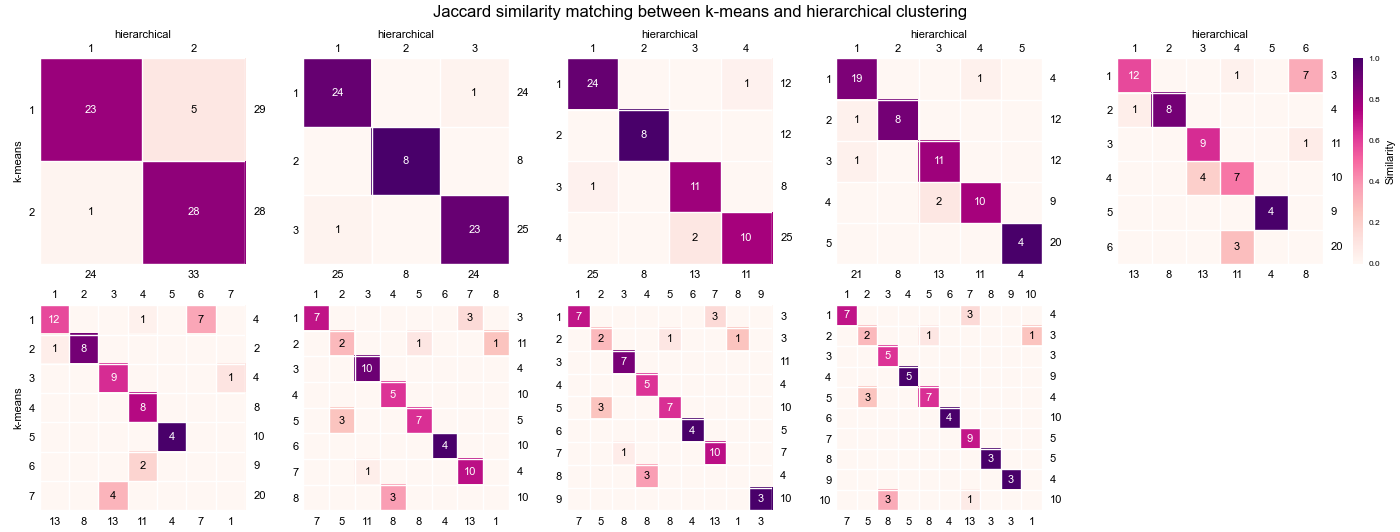

In [11]:
def jaccard_matrix(labels_1, labels_2, k):
    """
    Compute k x k Jaccard similarity matrix between two clusterings

        labels_1   reference labels
        labels_2   comparison labels
        k          k-value
        J          (k x k) Jaccard similarity matrix
        C          (k x k) counts matrix (intersection)
    """

    J = np.zeros((k, k))
    C = np.zeros((k, k), dtype=int)
    
    for i in range(k):
        A = (labels_1 == i)
        for j in range(k):
            B = (labels_2 == j)
            inter = np.sum(A & B)
            union = np.sum(A | B)

            C[i, j] = inter
            J[i, j] = inter / union if union > 0 else 0.0
    return J, C

def jaccard_align(obj1, obj2, k_range=k_range):
    """
    Compute k x k Jaccard similarity matrix between two clusterings,
    then align obj2 labels/centroids to reference obj1 labels/centroids using the
    Hungarian algorithm.

        obj1            reference object with .labels[k], .centroids[k] attributes
        obj2            comparison object with .labels[k], .centroids[k] attributes
        .J[k]           (k x k) aligned Jaccard matrix
        .C[k]           (k x k) aligned counts matrix (intersection)
        .perm[k]        permutation array: new label for obj2 aligned with reference obj1
        .labels[k]      permuted labels
        .centroids[k]   permuted centroids
    """

    # Initialize alignment structures
    obj2.J    = {}
    obj2.C    = {}
    obj2.perm = {}

    for k in k_range:

        # Compute initial Jaccard matrix
        J, C = jaccard_matrix(obj1.labels[k], obj2.labels[k], k)

        # Hungarian algorithm: maximize Jaccard by minimizing -J
        cost = -J
        row_ind, col_ind = linear_sum_assignment(cost)

        # .perm = new label for obj2
        obj2.perm[k] = np.argsort(col_ind)

        # Apply permutation to obj2 labels
        obj2.labels[k] = obj2.perm[k][obj2.labels[k]]

        # Recompute aligned J, C using aligned labels
        obj2.J[k], obj2.C[k] = jaccard_matrix(obj1.labels[k], obj2.labels[k], k)

        # Reindex centroids
        obj2.centroids[k] = obj2.centroids[k][np.argsort(obj2.perm[k])]

# Align all k-means variants to kmeans_default
jaccard_align(kmeans_default, kmeans_clean, k_range)
jaccard_align(kmeans_default, kmeans_norm,  k_range)
jaccard_align(kmeans_default, kmeans_pca,   k_range)

# Align all hierarchical variants to kmeans
jaccard_align(kmeans_clean, hier_clean, k_range)
jaccard_align(kmeans_norm, hier_norm, k_range)
jaccard_align(kmeans_pca, hier_pca, k_range)

# Optionally show diagnostic plots
if SHOW_PLOTS:

    plt.close('all')

    # Initialize figure based on k_range
    n_k   = len(k_vals)
    n_col = 5 # Figure = n_col wide
    n_row = (n_k + n_col - 1) // n_col # ceiling division
    
    fig, axes = plt.subplots(n_row, n_col, figsize=(max_plot_width, 0.19*max_plot_width*n_row), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.05)
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False
    fig.suptitle("Jaccard similarity matching between k-means and hierarchical clustering", fontsize=12)

    # Flatten axes for easy indexing
    axes = axes.flatten()

    # Map each k to an axis
    ax = {k: axes[i] for i, k in enumerate(k_vals)}
    
    # Delete unused axes (if any)
    for j in range(len(k_vals), len(axes)):
        fig.delaxes(axes[j])

    # Function to build jaccard similarity heatmaps
    def plot_jaccard_matrix(J, C, k, ax, title="", x_label="", y_label="", c_label="", show_cbar=True):

        # Heatmap of jaccard similarity
        im = ax.imshow(J, cmap="RdPu", vmin=0, vmax=1, aspect="equal", interpolation="none")
        
        # Remove black border
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Remove all tick marks
        ax.tick_params(axis="both", which="both", length=0)
        
        # White gridlines between cells
        ax.set_xticks(np.arange(k+1) - 0.5, minor=True)
        ax.set_yticks(np.arange(k+1) - 0.5, minor=True)
        ax.grid(which="minor", color=bg, linewidth=1)
        
        # Major ticks at cell centers
        ax.set_xticks(np.arange(k))
        ax.set_yticks(np.arange(k))

        # Hide bottom x labels
        ax.set_xticklabels([])
    
        # Left y labels
        ax.set_yticklabels(np.arange(1, k+1), fontsize=8)
    
        # Top x-axis labels
        ax_top = ax.secondary_xaxis("top")
        ax_top.set_xticks(np.arange(k))
        ax_top.set_xticklabels(np.arange(1, k+1), fontsize=8)
        ax_top.tick_params(axis="x", which="both", length=0)
        ax_top.spines["top"].set_visible(False)

        # Cell counts
        for i in range(k):
            for j in range(k):
                if C[i, j] == 0:
                    continue
                text_color = "black" if J[i, j] < 0.5 else "white"
                ax.text(j, i, str(C[i, j]), ha="center", va="center", fontsize=8, color=text_color)

        # Row sums (aligned to right of heatmap)
        row_sums = C.sum(axis=1)
        for i in range(k):
            ax.text(1.04, (i + 0.5) / k, str(row_sums[i]), ha="left", va="center", fontsize=8, color=fg, transform=ax.transAxes)

        # Column sums (aligned below heatmap)
        col_sums = C.sum(axis=0)
        for j in range(k):
            ax.text((j + 0.5) / k, -0.08, str(col_sums[j]), ha="center", va="bottom", fontsize=8, color=fg, transform=ax.transAxes)
        
        # Colorbar
        if show_cbar:
            cbar = ax.figure.colorbar(im, ax=ax, location="right", anchor=(0.0, 0.5), shrink=1.0, pad=0.04)
            cbar.set_label(c_label)
            cbar.outline.set_visible(False)
            cbar.ax.tick_params(which="both", length=0)

        # Labels
        ax.set_title(title)
        ax_top.set_xlabel(x_label)
        ax.set_ylabel(y_label)

    # Plot loop
    for i, k in enumerate(k_vals):
        row = i // n_col
        col = i % n_col
        
        x_label   = "hierarchical" if row == 0 else ""
        y_label   = "k-means"      if col == 0 else ""
        show_cbar = (col == n_col - 1)
        c_label   = "Similarity" if show_cbar else ""

        plot_jaccard_matrix(hier_default.J[k], hier_default.C[k], k, ax[k], x_label=x_label, y_label=y_label, c_label=c_label, show_cbar=show_cbar)

    plt.show()

Export Jaccard Similarity Figure

In [12]:
export_fig(fig, fig_name="Jaccard_Similarity_kMeans-Hierarchical")

Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Jaccard_Similarity_kMeans-Hierarchical.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Jaccard_Similarity_kMeans-Hierarchical.pdf


Categorical Analysis: clusters provided as categorical variables in input data

In [13]:
def categorical_analysis(data, cat_df):
    """
    Computes categorical-based analysis of centroids, silhouette, and ANOVA on input (clean, moralized, or PCA)
    Returns namespace with:
        .data:           input DataFrame        
        .category:       dict of categories (string)
        .labels:         dict of categories (numeric)
        .centroids:      dict of cluster centroids computed from mean in the input feature space
        .centroids_dist: dict of distances from each point to its assigned centroid
        .sil:            dict of global silhouette scores
        .sil_cell:       dict of per-cell silhouette scores
        .feature_anova:  dict of ANOVA tables per category, sorted by F
    """

    X = data.to_numpy(dtype=float)
    feature_names = data.columns

    # Initialize namespace
    out = SimpleNamespace(
        data           = data,
        category       = {},
        labels         = {},
        centroids      = {},
        centroids_dist = {},
        sil            = {},
        sil_cell       = {},
        feature_anova  = {}
    )

    # If no categorical columns, return empty namespace
    if cat_df is None or cat_df.empty:
        return out
    
    # Loop over categorical columns
    for cat in cat_df.columns:

        # Categorical labels (strings)
        cat_values = np.array(cat_df[cat])
        out.category[cat] = sorted(set(cat_values))

        # Numerical categories
        label_map = {val: i for i, val in enumerate(out.category[cat])}
        out.labels[cat] = np.array([label_map[v] for v in cat_values])

        # Compute centroids
        out.centroids[cat] = np.zeros((len(out.category[cat] ), X.shape[1]))
        for i in range(len(out.category[cat])):
            out.centroids[cat][i] = X[out.labels[cat] == i].mean(axis=0)
        out.centroids_dist[cat] = np.linalg.norm(X - out.centroids[cat][out.labels[cat]], axis=1)

        # Skip silhouette scores and ANOVAs if category has only 1 value
        if len(out.category[cat]) > 1:

            # Silhouette scores
            out.sil[cat] = silhouette_score(X, out.labels[cat])
            out.sil_cell[cat] = silhouette_samples(X, out.labels[cat])

            # ANOVA
            F, p = f_classif(X, out.labels[cat])
            p_bonf = np.minimum(p * len(p), 1.0)
            _, p_fdr, _, _ = multipletests(p, method='fdr_bh')
            df = pd.DataFrame([F, p, p_bonf, p_fdr], index=["F", "p", "p_bonf", "p_fdr"], columns=feature_names)
            df = df.loc[:, df.loc["F"].sort_values(ascending=False).index]
            out.feature_anova[cat] = df

        else:
            out.sil[cat] = None
            out.sil_cell[cat] = None
            out.feature_anova[cat] = None

    return out

cat_clean = categorical_analysis(data_clean, data_categorical)
cat_norm  = categorical_analysis(data_norm, data_categorical)
cat_pca   = categorical_analysis(data_pca, data_categorical)

Interactive 3D plot for k-means analysis

In [15]:
# Define global variables
_axes_updating  = False        # Boolean flag to indicate update_axis_options is currently running
_axes_selection = None         # Persistant axes selection values [x_axis, y_axis, z_axis]
_fig_plot3d     = None         # Persistant figure object for 3D plot
_leg_plot3d     = None         # Persistant legend object for 3D plot
_view_angles    = (20, 135, 0) # Persistant view angle values (elev, azim, roll) for 3D plot

# Define widgets
mode_plot3d_w  = widgets.Dropdown(options=["raw", "normalized", "pca"], value=mode_default, description="Data Mode")
k_plot3d_w     = widgets.Dropdown(options=list(k_range), value=k_default, description="k")
clust_plot3d_w = widgets.Dropdown(options=["k-means", "hierarchical"] + cat_cols, value="hierarchical", description="Clustering")
x_axis_w       = widgets.Dropdown(description="X Axis")
y_axis_w       = widgets.Dropdown(description="Y Axis")
z_axis_w       = widgets.Dropdown(description="Z Axis")
view_w         = widgets.Dropdown(options=["Default", "XY", "XZ", "YZ", "User"], value="Default", description="View")
labels_w       = widgets.Checkbox(value=True, description="Cell Labels")
centroids_w    = widgets.Checkbox(value=False, description="Centroids")
spokes_w       = widgets.Checkbox(value=False, description="Spokes")
hulls_w        = widgets.Checkbox(value=True, description="Convex Hulls")
ellips_w       = widgets.Checkbox(value=False, description="Ellipsoids")
exp_plot3d_w   = widgets.Button(description="Export", layout=widgets.Layout(width="70%", height="30px", margin="4px 2px 1px auto", padding="0"))
plot3d_leg_w   = widgets.Output()
plot3d_out_w   = widgets.Output()

def select_kmeans_data(mode, k):
    if mode == "raw":
        obj = kmeans_clean
    elif mode == "normalized":
        obj = kmeans_norm
    elif mode == "pca":
        obj = kmeans_pca

    return (
        obj.data,
        obj.kmeans[k],
        obj.labels[k],
        obj.centroids[k],
        obj.centroids_dist[k],
        obj.sil_cell[k],
        obj.feature_anova[k]
    )

# Helper function to select correct hierarchical analysis metrics based on widget selection
def select_hier_data(mode, k):
    if mode == "raw":
        obj = hier_clean
    elif mode == "normalized":
        obj = hier_norm
    elif mode == "pca":
        obj = hier_pca

    return (
        obj.data,
        obj.Z,
        obj.labels[k],
        obj.centroids[k],
        obj.centroids_dist[k],
        obj.sil_cell[k],
        obj.feature_anova[k]
    )

# Helper function to select correct categorical analysis metrics based on widget selection
def select_cat_data(mode, cat):
    if mode == "raw":
        obj = cat_clean
    elif mode == "normalized":
        obj = cat_norm
    elif mode == "pca":
        obj = cat_pca

    return (
        obj.data,
        obj.category[cat],
        obj.labels[cat],
        obj.centroids[cat],
        obj.centroids_dist[cat],
        obj.sil_cell[cat],
        obj.feature_anova[cat]
    )

# Helper function to update axis options based on selected data mode and k
def update_axis_options(mode, k, clustering):
    global _axes_selection

    if clustering == "k-means":
        data_plot, _, _, _, _, _, feature_anova = select_kmeans_data(mode, k)
    elif clustering == "hierarchical":
        data_plot, _, _, _, _, _, feature_anova = select_hier_data(mode, k)
    elif clustering in cat_cols:
        data_plot, _, _, _, _, _, feature_anova = select_cat_data(mode, clustering)
    else:
        raise ValueError(f"Unknown clustering mode: {clustering}")
    
    # Determine new feature ordering based on ANOVA
    if feature_anova is None: # fallback: use raw column order
        cols = list(data_plot.columns)
    else:
        cols = list(feature_anova.columns)

    # Update drop-downs - sorted by ANOVA feature relevance
    x_axis_w.options = cols
    y_axis_w.options = cols
    z_axis_w.options = cols

    # Update selections if old axes
    if _axes_selection is None or any(ax not in cols for ax in _axes_selection):
        x_axis_w.value = cols[0]
        y_axis_w.value = cols[1]
        z_axis_w.value = cols[2]
    else:
        # Restore previous valid selection
        x_axis_w.value, y_axis_w.value, z_axis_w.value = _axes_selection

    # Update persistant axes selection
    _axes_selection = [x_axis_w.value, y_axis_w.value, z_axis_w.value]

# Build control panel + legend
controls_plot3d = widgets.VBox([
    widgets.Label(""), mode_plot3d_w, k_plot3d_w, clust_plot3d_w,
    x_axis_w, y_axis_w, z_axis_w, view_w, 
    labels_w, centroids_w, spokes_w, hulls_w, ellips_w, 
    exp_plot3d_w, widgets.Label(""), plot3d_leg_w
    ])

# Helper function to plot covariance ellipsoid for clusters
def plot_ellipsoid(ax, center, cov, color, alpha=0.4):
    # Eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Radii = sqrt eigenvalues (1-sigma)
    radii = np.sqrt(eigvals)

    # Sphere mesh
    u = np.linspace(0, 2*np.pi, 20)
    v = np.linspace(0, np.pi, 20)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    # Transform sphere → ellipsoid
    ellipsoid = np.array([xs, ys, zs]).reshape(3, -1)
    ellipsoid = (eigvecs @ np.diag(radii) @ ellipsoid).T + center

    X = ellipsoid[:,0].reshape(xs.shape)
    Y = ellipsoid[:,1].reshape(xs.shape)
    Z = ellipsoid[:,2].reshape(xs.shape)

    ax.plot_surface(X, Y, Z, rstride=1, cstride=1, color=color, alpha=alpha, linewidth=0)

# Helper function to assign correct units (for raw mode)
def axis_label(col, mode):
    if mode == "raw":
        unit = units.get(col, "")
        return f"{col} ({unit})" if unit else col
    else:
        return col

# Define rotation handler to detect manual view changes and update view mode accordingly
def _on_rotate(event):
    global _view_angles

    # Ensure only fires for 3D axes
    ax = event.inaxes
    if ax is None:
        return
    if not hasattr(ax, "elev") or not hasattr(ax, "azim"):
        return

    # Ensure only fires for dragging left mouse button
    if event.button != 1:
        return

    current = (ax.elev, ax.azim, ax.roll)

    # Detect real manual rotation
    if _view_angles is not None and current != _view_angles:
        view_w.value = "User"

    _view_angles = current

# Export plot button handler
def _export_plot3d(_):
    if _fig_plot3d is not None:
        export_fig(fig=_fig_plot3d)
    else:
        print("No 3D figure available to export.")

    if _leg_plot3d is not None:
        export_fig(fig=_leg_plot3d, fig_name="3D_Scatter_Plot_legend")
    else:
        print("No 3D legend available to export.")
# Attach handler
exp_plot3d_w.on_click(_export_plot3d)

# 3D scatter plot function of k-means analysis
def plot3d(mode, k, clustering, x_axis, y_axis, z_axis, view, show_labels, show_centroids, show_spokes, show_hulls, show_ellipsoids):
    global _view_angles

    # Select data and labels based on clustering method
    if clustering == "k-means":
        data_plot, _, labels, centroids, _, _, _ = select_kmeans_data(mode, k)
    elif clustering == "hierarchical":
        data_plot, _, labels, centroids, _, _, _ = select_hier_data(mode, k)
    elif clustering in cat_cols:
        data_plot, _, labels, centroids, _, _, _ = select_cat_data(mode, clustering)
    else:
        raise ValueError(f"Unknown clustering mode: {clustering}")
    
    n_groups = len(np.unique(labels))

    x = data_plot[x_axis].values
    y = data_plot[y_axis].values
    z = data_plot[z_axis].values
    
    # Update colors
    colors = [palette[l] for l in labels]
  
    fig = plt.figure(figsize=(max_plot_width-3, max_plot_width*4/7))
    fig.canvas.header_visible = False
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(x, y, z, c=colors, s=50, depthshade=False)

    # ax.set_proj_type('ortho') # Orthographic (no perspective)
    ax.set_box_aspect([1, 1, 1], zoom=1.1)

    # Titles
    ax.set_title(f"3D Scatter Plot ({mode}, {n_groups} clusters, {clustering})")
    ax.set_xlabel(axis_label(x_axis, mode))
    ax.set_ylabel(axis_label(y_axis, mode))
    ax.set_zlabel(axis_label(z_axis, mode))

    # Remove 3D background planes
    ax.xaxis.pane.set_visible(False)
    ax.yaxis.pane.set_visible(False)
    ax.zaxis.pane.set_visible(False)

    # Keep grid lines visible
    ax.grid(True)

    # Adjust gridline colors
    grid_rgb = to_rgb(fg)  # fg = "white" or "black"
    ax.xaxis._axinfo["grid"]["color"] = (*grid_rgb, 0.1)
    ax.yaxis._axinfo["grid"]["color"] = (*grid_rgb, 0.1)
    ax.zaxis._axinfo["grid"]["color"] = (*grid_rgb, 0.1)
    ax.xaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.yaxis._axinfo["grid"]["linewidth"] = 0.5
    ax.zaxis._axinfo["grid"]["linewidth"] = 0.5

    # View Presets
    if view == "Default":
        ax.view_init(elev=20, azim=135, roll=0)
    elif view == "XY":
        ax.view_init(elev=90, azim=-90, roll=0)
    elif view == "XZ":
        ax.view_init(elev=0, azim=-90, roll=0)
    elif view == "YZ":
        ax.view_init(elev=0, azim=0, roll=0)
    elif view == "User": # Restore manual angles
        ax.view_init(elev=_view_angles[0], azim=_view_angles[1], roll=_view_angles[2])

    # Attach rotation handler to figure canvas to detect manual view changes
    fig.canvas.mpl_connect("button_release_event", _on_rotate)

    # Option: cell labels
    if show_labels:
        for i, name in enumerate(cell_name):
            ax.text(x[i], y[i], z[i], name, fontsize=8, color=fg, alpha=0.7)

    # Option: centroids
    if show_centroids:
        for i in range(n_groups):
            c = centroids[i]
            cx = c[data_plot.columns.get_loc(x_axis)]
            cy = c[data_plot.columns.get_loc(y_axis)]
            cz = c[data_plot.columns.get_loc(z_axis)]
            ax.scatter(cx, cy, cz, c=[palette[i]], s=200, marker='P', edgecolor=fg, linewidth=1)

    # Option: Spokes from point → centroid lines
    if show_spokes:
        for i in range(n_groups):
            mask = labels == i
            c = centroids[i]
            cx = c[data_plot.columns.get_loc(x_axis)]
            cy = c[data_plot.columns.get_loc(y_axis)]
            cz = c[data_plot.columns.get_loc(z_axis)]
            for px, py, pz in zip(x[mask], y[mask], z[mask]):
                ax.plot([cx, px], [cy, py], [cz, pz], color=palette[i], alpha=0.4)

    # Option: Convex hulls
    axes_unique = (x_axis != y_axis) and (x_axis != z_axis) and (y_axis != z_axis)
    if show_hulls and axes_unique:
        for i in range(n_groups):
            mask = labels == i
            pts = np.vstack([x[mask], y[mask], z[mask]]).T

            if pts.shape[0] >= 4:
                hull = ConvexHull(pts)
                faces = [pts[simplex] for simplex in hull.simplices]
                poly = Poly3DCollection(faces, alpha=0.2)
                poly.set_facecolor(palette[i])
                poly.set_edgecolor(palette[i])
                ax.add_collection3d(poly)

    # Option: Covariance ellipsoids
    if show_ellipsoids:
        for i in range(n_groups):
            mask = labels == i
            pts = np.vstack([x[mask], y[mask], z[mask]]).T

            if pts.shape[0] >= 4:
                center = pts.mean(axis=0)
                cov = np.cov(pts, rowvar=False)
                plot_ellipsoid(ax, center, cov, palette[i], alpha=0.5) 

    plt.tight_layout()
    return fig

# Legend Plotting Function
def plot3d_legend(k, clustering):

    if clustering == "k-means":
        marker = 'o'
        label = [f"Cluster {i+1}" for i in range(k)]
    elif clustering == "hierarchical":
        marker = '|'
        label = [f"Branch {i+1}" for i in range(k)]
    elif clustering in cat_cols:
        marker = 's'
        _, category, _, _, _, _, _ = select_cat_data("raw", clustering) # mode doesn't matter
        label = [str(i) for i in category]
    else:
        raise ValueError(f"Unknown clustering mode: {clustering}")
    
    fig, ax = plt.subplots(figsize=(2.5, 0.25 * len(label)))
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False
    fig.canvas.toolbar_visible = False
    fig.canvas.resizable = False
    ax.axis('off')

    # Build legend items
    handles = [
        plt.Line2D([0], [0],
                   marker=marker,
                   color='none',
                   markerfacecolor=palette[i],
                   markeredgecolor=palette[i],
                   markersize=8,
                   linestyle='none',
                   label=label[i])
        for i in range(len(label))
    ]
          
    ax.legend(handles=handles, loc='center', frameon=False)
    return fig

# Unified widget change function
def _on_widget_change(change):
    global _axes_selection, _axes_updating, _fig_plot3d, _leg_plot3d

    w = change.owner  # widget that changed

    # If w = view, and value is programatically set to "User", do not trigger update
    if w is view_w and view_w.value == "User":
        return

    # If w = axis, update persistent axes selection, ignoring events caused by update_axis_options
    if w in (x_axis_w, y_axis_w, z_axis_w):
        if _axes_updating:
            return
        _axes_selection = [x_axis_w.value, y_axis_w.value, z_axis_w.value]

    # If w = mode/k/clustering, update axis options
    if w in (mode_plot3d_w, k_plot3d_w, clust_plot3d_w):
        _axes_updating = True
        update_axis_options(mode_plot3d_w.value, k_plot3d_w.value, clust_plot3d_w.value)
        _axes_updating = False
    
    # Update legend
    with plot3d_leg_w:
        plot3d_leg_w.clear_output(wait=True)
        plt.close('all')
        _leg_plot3d = plot3d_legend(k_plot3d_w.value, clust_plot3d_w.value)
        plt.show()

    # Update plot
    with plot3d_out_w:
        plot3d_out_w.clear_output(wait=True)
        _fig_plot3d = plot3d(
            mode_plot3d_w.value,
            k_plot3d_w.value,
            clust_plot3d_w.value,
            x_axis_w.value,
            y_axis_w.value,
            z_axis_w.value,
            view_w.value,
            labels_w.value,
            centroids_w.value,
            spokes_w.value,
            hulls_w.value,
            ellips_w.value
        )
        plt.show()

# Add observor to all widgets to trigger _on_widget_change
for w in [
    mode_plot3d_w, k_plot3d_w, clust_plot3d_w,
    x_axis_w, y_axis_w, z_axis_w,
    view_w, labels_w, centroids_w,
    spokes_w, hulls_w, ellips_w
]:
    w.observe(_on_widget_change, names="value")

# Display widgets
display(widgets.HBox([controls_plot3d, plot3d_out_w]))

# Trigger widget update
clust_plot3d_w.value = "k-means"

Export 3D plot and legend

In [16]:
if _fig_plot3d is not None:
    export_fig(fig=_fig_plot3d)
else:
    print("No 3D figure available to export.")

if _leg_plot3d is not None:
    export_fig(fig=_leg_plot3d, fig_name="3D_Scatter_Plot_legend")
else:
    print("No 3D legend available to export.")

Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\3D_Scatter_Plot_pca_5_clusters_k-means_.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\3D_Scatter_Plot_pca_5_clusters_k-means_.pdf
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\3D_Scatter_Plot_legend.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\3D_Scatter_Plot_legend.pdf


Prepare output data table, compute summary stats for currently selected k-means analysis

In [17]:
# Prepare output dataframes
def prepare_data_out(data_numeric):
    data_out = data_numeric.copy()
    data_out = pd.concat([data_categorical, data_out], axis=1) # Recombine categorial and numerical data
    data_out.insert(0, lab_cols[0], cell_name) # Reinsert "Cell" column
    data_out.insert(1, lab_cols[1], cell_ID)   # Reinsert "Cell_ID" column
    return data_out

data_out_clean = prepare_data_out(data_clean)
data_out_norm  = prepare_data_out(data_norm)
data_out_pca   = prepare_data_out(data_pca)

# Append k-means clustering results
def append_kmeans_cluster(data_out, mode, k):
    _, _, labels, _, centroids_dist, sil_cell, _ = select_kmeans_data(mode, k)
    data_out["kmeans_cluster"]          = labels + 1
    data_out["kmeans_silscore"]         = sil_cell
    data_out["kmeans_dist_to_centroid"] = centroids_dist
    return data_out

data_out_clean = append_kmeans_cluster(data_out_clean, "raw", k_plot3d_w.value)
data_out_norm  = append_kmeans_cluster(data_out_norm, "normalized", k_plot3d_w.value)
data_out_pca   = append_kmeans_cluster(data_out_pca, "pca", k_plot3d_w.value)

# Compute summary statistics
summary_kmeans = data_out_clean.groupby("kmeans_cluster")[num_cols].agg(["mean", "std"])
summary_kmeans.T.xs("mean", level=1)

kmeans_cluster,1,2,3,4,5
tau,38.233333,13.991089,20.219079,27.703925,18.40000
Rin,838.333333,123.922807,283.818191,626.962667,271.00000
sag_ratio,0.966667,0.876305,0.913332,0.945554,0.93500
freq_max,13.666667,73.700000,40.636364,30.875000,76.00000
delay_spike,29.666667,118.692000,119.256364,286.022500,971.00000
freq_ratio,0.125000,0.652517,0.405922,0.357129,0.71463
half_width,1.000000,0.754500,0.990000,0.936250,0.78250
max_up,156.333333,219.335500,151.561116,135.724163,198.50000
max_down,-71.000000,-99.789245,-64.583443,-55.715650,-75.75000
AHP_time,4.766667,4.510999,8.549091,6.911248,4.90000


Interactive plot for hierarchical analysis

In [18]:
# Define global variables
_fig_hier    = None # Persistant figure object for hierarchical plot
_leg_hier    = None # Persistant legend object for hierarchical plot

# Options
plot_dots = True   # True → colored circle markers beneath each leaf, # False → colored text labels

# Define widgets
mode_hier_w  = widgets.Dropdown(options=["raw", "normalized", "pca"], value=mode_default, description="Data Mode")
k_hier_w     = widgets.Dropdown(options=list(k_range), value=k_default, description="k")
clust_hier_w = widgets.Dropdown(options=["k-means", "hierarchical"] + cat_cols, value="hierarchical", description="Clustering")
exp_hier_w   = widgets.Button(description="Export", layout=widgets.Layout(width="70%", height="30px", margin="4px 2px 1px auto", padding="0"))
hier_leg_w   = widgets.Output()
hier_out_w   = widgets.Output()

# Build control panel + legend
controls_hier = widgets.VBox([widgets.Label(""), mode_hier_w, k_hier_w, clust_hier_w, exp_hier_w, widgets.Label(""), hier_leg_w])

# Export plot button handler
def _export_hier(_):
    if _fig_hier is not None:
        export_fig(fig=_fig_hier)
    else:
        print("No hierarchical figure available to export.")

    if _leg_hier is not None:
        export_fig(fig=_leg_hier, fig_name="Hierarchical_Clustering_Dendrogram_legend")
    else:
        print("No hierarchical legend available to export.")
# Attach handler
exp_hier_w.on_click(_export_hier)

# Hierarchical Plotting Function
def plot_hierarchical(mode, k, clustering):
    
    data_plot, Z, labels_hier, _, _, _, _ = select_hier_data(mode, k)
    n = len(data_plot)

    # Select data and labels based on clustering method
    if clustering == "k-means":
        _, _, labels, _, _, _, _ = select_kmeans_data(mode, k)
    elif clustering == "hierarchical":
        labels = labels_hier
    elif clustering in cat_cols:
        _, _, labels, _, _, _, _ = select_cat_data(mode, clustering)
    else:
        raise ValueError(f"Unknown clustering mode: {clustering}")
    
    n_groups = len(np.unique(labels))

    # Branch color logic for each clustering method
    branch_color = {}
    children = defaultdict(list)
    if clustering == "hierarchical":

        for i in range(n):
            children[i] = [i]
        for node_id, (c1, c2, _, _) in enumerate(Z, start=n):
            children[node_id] = children[int(c1)] + children[int(c2)]

        for merge_idx in range(Z.shape[0]):
            node_id = n + merge_idx
            leaf_ids = children[node_id]
            cluster_ids = {labels[i] for i in leaf_ids}
            if len(cluster_ids) == 1:
                cid = cluster_ids.pop()
                branch_color[merge_idx] = matplotlib.colors.to_hex(palette[cid])
            else:
                branch_color[merge_idx] = fg

    else: # k-means or categorical: color bottom-most branches whose leaves all share the same label

        for i in range(n):
            children[i] = [i]
        for node_id, (c1, c2, _, _) in enumerate(Z, start=n):
            children[node_id] = children[int(c1)] + children[int(c2)]

        for merge_idx in range(Z.shape[0]):
            node_id = n + merge_idx
            leaf_ids = children[node_id]
            cluster_ids = {labels[i] for i in leaf_ids}

            if len(cluster_ids) == 1:
                cid = cluster_ids.pop()
                branch_color[merge_idx] = matplotlib.colors.to_hex(palette[cid])
            else:
                branch_color[merge_idx] = fg

    def link_color_func(node_id):
        if node_id < n:
            return fg
        merge_idx = node_id - n
        return branch_color.get(merge_idx, fg)

    # Plot
    fig, ax = plt.subplots(figsize=(max_plot_width-7, max_plot_width*3/7))
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    dendro = dendrogram(Z, labels=cell_name, leaf_rotation=90, leaf_font_size=8, link_color_func=link_color_func, ax=ax)

    # Leaf colors: align via dendro["leaves"]
    leaf_order = dendro["leaves"] # indices into data_plot / labels

    if plot_dots:
        # Hide the text tick labels and draw a colored circle for each leaf
        ax.set_xticklabels([])      # remove text
        ax.tick_params(axis='x', length=0)  # remove tick marks too

        # x positions of leaves are 5, 15, 25 … (dendro uses 10-unit spacing)
        x_positions = ax.get_xticks()

        # y position: just below the axis (in data coordinates)
        y_dot = -0.02 * ax.get_ylim()[1]

        for x, idx in zip(x_positions, leaf_order):
            cid = labels[idx]
            ax.plot(x, y_dot,
                    marker='o',
                    color=matplotlib.colors.to_hex(palette[cid]),
                    markersize=5,
                    clip_on=False,
                    transform=ax.transData)
    else:
        # Color the text labels
        for lbl, idx in zip(ax.get_xmajorticklabels(), leaf_order):
            cid = labels[idx]
            lbl.set_color(matplotlib.colors.to_hex(palette[cid]))
        ax.set_xlabel("Cell")

    sns.despine(ax=ax)
    ax.set_title(f"Hierarchical Clustering Dendrogram ({mode}, {n_groups} clusters, {clustering})")
    ax.set_ylabel("Linkage Distance")
    plt.tight_layout()
    return fig

# Legend Plotting Function
def plot_hier_legend(k, clustering):

    if clustering == "k-means":
        marker = 'o'
        label = [f"Cluster {i+1}" for i in range(k)]
    elif clustering == "hierarchical":
        marker = '|'
        label = [f"Branch {i+1}" for i in range(k)]
    elif clustering in cat_cols:
        marker = 's'
        _, category, _, _, _, _, _ = select_cat_data("raw", clustering) # mode doesn't matter
        label = [str(i) for i in category]
    else:
        raise ValueError(f"Unknown clustering mode: {clustering}")
    
    fig, ax = plt.subplots(figsize=(2.5, 0.25 * len(label)))
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False
    fig.canvas.toolbar_visible = False
    fig.canvas.resizable = False
    ax.axis('off')

    # Build legend items
    handles = [
        plt.Line2D([0], [0],
                   marker=marker,
                   color='none',
                   markerfacecolor=palette[i],
                   markeredgecolor=palette[i],
                   markersize=8,
                   linestyle='none',
                   label=label[i])
        for i in range(len(label))
    ]

    ax.legend(handles=handles, loc='center', frameon=False)
    return fig

# Function to update plot and legend when any relevant widget changes
def update_hier(mode, k, clustering):
    global _fig_hier, _leg_hier

    with hier_leg_w:
        hier_leg_w.clear_output(wait=True)
        plt.close('all')
        _leg_hier = plot_hier_legend(k, clustering)
        plt.show()

    with hier_out_w:
        hier_out_w.clear_output(wait=True)
        _fig_hier = plot_hierarchical(mode, k, clustering)
        plt.show()

# Connect widgets to update function
interactive_hier = widgets.interactive_output(
    update_hier,
    {
        "mode": mode_hier_w,
        "k": k_hier_w,
        "clustering": clust_hier_w
    }
)

display(widgets.HBox([controls_hier, hier_out_w]))

Export dendrogram and legend

In [19]:
if _fig_hier is not None:
    export_fig(fig=_fig_hier)
else:
    print("No hierarchical figure available to export.")

if _leg_hier is not None:
    export_fig(fig=_leg_hier, fig_name="Hierarchical_Clustering_Dendrogram_legend")
else:
    print("No hierarchical legend available to export.")

Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Hierarchical_Clustering_Dendrogram_pca_5_clusters_hierarchical_.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Hierarchical_Clustering_Dendrogram_pca_5_clusters_hierarchical_.pdf
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Hierarchical_Clustering_Dendrogram_legend.svg
Exported figure DataTable_CGE-Transplant_Final-noFS_260715_0910\Hierarchical_Clustering_Dendrogram_legend.pdf


Summary stats for currently selected hierarchical analysis, append to output data

In [20]:
# Append hierarchical clustering results
def append_hier_cluster(data_out, mode, k):
    _, _, labels, _, centroids_dist, sil_cell, _ = select_hier_data(mode, k)
    data_out["hier_cluster"]          = labels + 1
    data_out["hier_silscore"]         = sil_cell
    data_out["hier_dist_to_centroid"] = centroids_dist
    return data_out

data_out_clean = append_hier_cluster(data_out_clean, "raw", k_hier_w.value)
data_out_norm  = append_hier_cluster(data_out_norm, "normalized", k_hier_w.value)
data_out_pca   = append_hier_cluster(data_out_pca, "pca", k_hier_w.value)

# Compute summary statistics
summary_hier = data_out_clean.groupby("hier_cluster")[num_cols].agg(["mean", "std"])
summary_hier.T.xs("mean", level=1)

hier_cluster,1,2,3,4,5
tau,13.995330,14.715612,20.260987,30.575581,18.40000
Rin,128.552973,134.196144,290.200010,684.609212,271.00000
sag_ratio,0.913324,0.861634,0.917666,0.951312,0.93500
freq_max,50.833333,76.812500,41.700000,26.181818,76.00000
delay_spike,320.586667,58.895000,106.582000,216.107273,971.00000
freq_ratio,0.477367,0.694669,0.400086,0.293821,0.71463
half_width,1.131667,0.681250,0.959000,0.953636,0.78250
max_up,158.116333,233.563250,151.767227,141.344845,198.50000
max_down,-57.437400,-110.635031,-65.091788,-59.884109,-75.75000
AHP_time,9.888331,3.361875,8.259000,6.326363,4.90000


Export data to xlsx

In [21]:
# Helper function to format excel tables
def format_excel_file(filename, df):

    # Load workbook
    wb = openpyxl.load_workbook(filename)
    ws = wb.active

    # Freeze panes
    ws.freeze_panes = "C2"

    # Determine full range
    nrows = df.shape[0] + 1   # header + data
    ncols = df.shape[1]
    last_col = get_column_letter(ncols)

    # Apply number format 0.0000 to entire data range (including headers)
    for row in ws.iter_rows(min_row=1, max_row=nrows, min_col=1, max_col=ncols):
        for cell in row:
            cell.number_format = "0.0000"

    # Add AutoFilter to entire range
    ws.auto_filter.ref = f"A1:{last_col}{nrows}"

    wb.save(filename)

file_out_clean = os.path.join(dir_out, base_name + "_clean_out.xlsx")
file_out_norm  = os.path.join(dir_out, base_name + "_norm_out.xlsx")
file_out_pca   = os.path.join(dir_out, base_name + "_pca_out.xlsx")

data_out_clean.to_excel(file_out_clean, index=False)
data_out_norm.to_excel(file_out_norm, index=False)
data_out_pca.to_excel(file_out_pca, index=False)

format_excel_file(file_out_clean, data_out_clean)
format_excel_file(file_out_norm, data_out_norm)
format_excel_file(file_out_pca, data_out_pca)

print(f"Output saved to {file_out_clean}")
print(f"Output saved to {file_out_norm}")
print(f"Output saved to {file_out_pca}")

Output saved to DataTable_CGE-Transplant_Final-noFS_260715_0910\DataTable_CGE-Transplant_Final-noFS_clean_out.xlsx
Output saved to DataTable_CGE-Transplant_Final-noFS_260715_0910\DataTable_CGE-Transplant_Final-noFS_norm_out.xlsx
Output saved to DataTable_CGE-Transplant_Final-noFS_260715_0910\DataTable_CGE-Transplant_Final-noFS_pca_out.xlsx
